# Model Registry
El Registry es simplemente un catálogo oficial donde los modelos aprobados reciben una etiqueta de estado.

Las etapas clásicas (Lifecycle Stages) son:

**None**: Recién registrado, sin revisar.

**Staging** (Entorno de Pruebas): El modelo es bueno y está listo para que el equipo de QA (Control de Calidad) o los ingenieros lo prueben con datos simulados.

**Production** (Producción): El modelo está activamente clasificando pozos petroleros en la vida real.

**Archived** (Archivado): El modelo quedó obsoleto y fue reemplazado, pero se guarda por temas de auditoría.

Ejemplo de modelo no registrado:
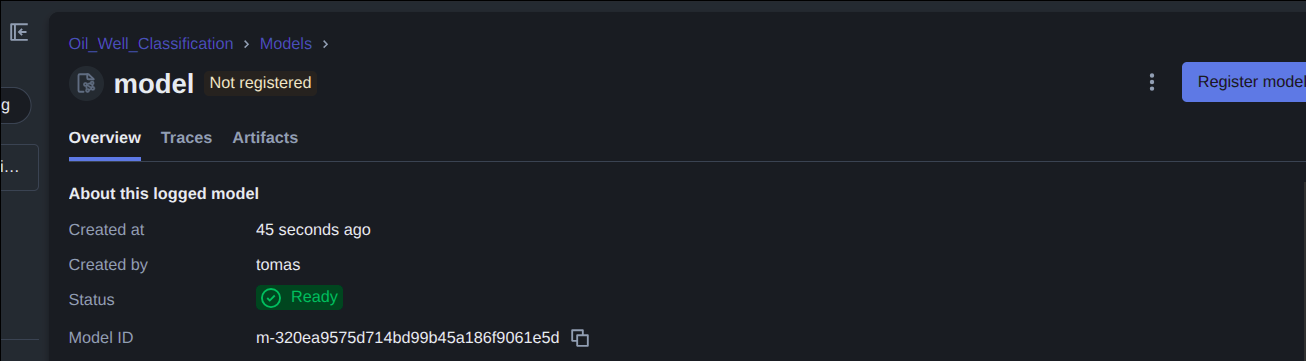

### Automatización con MlflowClient

En lugar de que un humano mire gráficos, se crea un script que usa la clase MlflowClient:

El script busca automáticamente en tu base de datos SQLite todos los intentos (runs).

Los ordena por f1_score de mayor a menor.

Toma el Run ID del ganador absoluto.

Se lo inscribe en el Model Registry bajo el nombre "Second-Random-Forest".

Lo sube a la etapa de "Staging".

In [30]:
# Abre una línea directa de comunicación con la base de datos de MLflow. 
# Actúa como tu "asistente". Le preguntas qué experimentos existen y le pides que cree uno nuevo.

import mlflow
from mlflow.tracking import MlflowClient

MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"

client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [31]:
client.search_experiments()


[<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1778531253981, experiment_id='2', last_update_time=1778531253981, lifecycle_stage='active', name='my-experiment', tags={}, trace_location=None, workspace='default'>,
 <Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1777925147971, experiment_id='1', last_update_time=1777925147971, lifecycle_stage='active', name='Oil_Well_Classification', tags={}, trace_location=None, workspace='default'>,
 <Experiment: artifact_location='mlflow-artifacts:/0', creation_time=1777925097983, experiment_id='0', last_update_time=1777925097983, lifecycle_stage='active', name='Default', tags={}, trace_location=None, workspace='default'>]

In [32]:
client.create_experiment("my-experiment")

RestException: RESOURCE_ALREADY_EXISTS: Experiment(name=my-experiment) already exists. Error: (sqlite3.IntegrityError) UNIQUE constraint failed: experiments.workspace, experiments.name
[SQL: INSERT INTO experiments (name, workspace, artifact_location, lifecycle_stage, creation_time, last_update_time) VALUES (?, ?, ?, ?, ?, ?)]
[parameters: ('my-experiment', 'default', '', 'active', 1778613374346, 1778613374346)]
(Background on this error at: https://sqlalche.me/e/20/gkpj)

In [ ]:
# Es el motor de búsqueda. Le dice a MLflow: "Busca en el experimento 1, tráeme solo los modelos donde la metrica f1 score 
# , ordénalos del mejor al peor, y dame solo los 5 primeros"

from mlflow.entities import ViewType
# Para un experimento, ver cuales son los mejores modelos o las mejores ejecuciones

runs = client.search_runs(experiment_ids=["1"],
                        filter_string='', # EN este caso no se agregan filtros pero se podrían agregar, por ejemplo, "metrics.rmse < 7"
                        run_view_type=ViewType.ACTIVE_ONLY, 
                        max_results=5,
                        order_by=["metrics.f1 ASC"])

In [ ]:
# Imprime las métricas de cada una de las ejecuciones encontradas

for run in runs:
    print(f"Run ID: {run.info.run_id}, F1 Score: {run.data.metrics['f1_score']}")

Run ID: 21c438b969b34930b5d7e398150d0d83, F1 Score: 1.0
Run ID: 629acd020a62486c88a9577425cb5c42, F1 Score: 1.0
Run ID: ad3d9611355e41c2b61ac4023b52135b, F1 Score: 1.0
Run ID: 7be18ea43cb1478ebc0ce0de5a6b42ce, F1 Score: 1.0
Run ID: d744c9568e8b4bb995800f00b994bf92, F1 Score: 1.0


In [ ]:
# Incribo el modelo elegido en el catálogo de modelos de MLflow

run_id = '21c438b969b34930b5d7e398150d0d83'
model_uri = f"runs:/{run_id}/model"
mlflow.register_model(model_uri=model_uri, name="Second-Random-Forest")

#Probar para que se vea version > 1


Registered model 'Second-Random-Forest' already exists. Creating a new version of this model...
2026/05/11 18:53:45 WARNING mlflow.tracking._model_registry.fluent: Run with id 21c438b969b34930b5d7e398150d0d83 has no artifacts at artifact path 'model', registering model based on models:/m-320ea9575d714bd99b45a186f9061e5d instead
2026/05/11 18:53:46 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Second-Random-Forest, version 2
Created version '2' of model 'Second-Random-Forest'.


<ModelVersion: aliases=[], creation_timestamp=1778536425351, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1778536425351, metrics=None, model_id=None, name='Second-Random-Forest', params=None, run_id='21c438b969b34930b5d7e398150d0d83', run_link='', source='models:/m-320ea9575d714bd99b45a186f9061e5d', status='READY', status_message=None, tags={}, user_id='', version='2', workspace='default'>

In [33]:
# Ver y cambiar el Estado (Lifecycle Stage)

model_name = "Second-Random-Forest"
latest_version= client.get_latest_versions(name=model_name)

for version in latest_version:
    print(f"Version: {version.version}, Stage: {version.current_stage}")

# Cambiamos de estapa la V2 a Staging
client.transition_model_version_stage(
    name=model_name,
    version=2,
    stage="Staging",
    archive_existing_versions=False
)

/tmp/ipykernel_59176/2866021211.py:4: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version= client.get_latest_versions(name=model_name)
/tmp/ipykernel_59176/2866021211.py:10: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


Version: 1, Stage: Staging
Version: 2, Stage: None


<ModelVersion: aliases=[], creation_timestamp=1778536425351, current_stage='Staging', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1778613817084, metrics=None, model_id=None, name='Second-Random-Forest', params=None, run_id='21c438b969b34930b5d7e398150d0d83', run_link='', source='models:/m-320ea9575d714bd99b45a186f9061e5d', status='READY', status_message=None, tags={}, user_id='', version='2', workspace='default'>

In [ ]:
# Comprobamos que se haya cambiado la etapa (Se pasa el V1 a production manualmente para que se vea el cambio)
latest_version= client.get_latest_versions(name=model_name)
for version in latest_version:
    print(f"Version: {version.version}, Stage: {version.current_stage}")




Version: 1, Stage: Staging
Version: 2, Stage: Production


/tmp/ipykernel_59176/619321734.py:2: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version= client.get_latest_versions(name=model_name)


### Producción vs. Staging
Ciclo de vida real:
Tienes la Versión 1 de tu modelo funcionando bien.

Hoy entrenaste la Versión 2 y la pusiste en Staging.

Antes de reemplazar la V1, descargas ambas versiones desde el Registry, les pasas un set de datos completamente nuevo y comparas: 

"¿La V2 de Staging es realmente mejor y más rápida que la V1?". 

Solo si la respuesta es sí, cambias las etiquetas y la V2 pasa a Producción, mientras la V1 se Archiva.

#### Shadow Testing

In [40]:
# Carga del preprocesamiento de datos (En el caso actual no se utiliza, por lo que está comentado)

'''

# Descarga el preprocesador guardado en MLflow
client.download_artifacts(run_id=run_id, path='preprocessor', dst_path='.')
with open("preprocessor/preprocessor.b", "rb") as f_in:
    dv = pickle.load(f_in)

'''

'\n\n# Descarga el preprocesador guardado en MLflow\nclient.download_artifacts(run_id=run_id, path=\'preprocessor\', dst_path=\'.\')\nwith open("preprocessor/preprocessor.b", "rb") as f_in:\n    dv = pickle.load(f_in)\n\n'

In [ ]:
# Cargamos el dataset de prueba
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score



def procesar_pozo(arch): # Código usado en parquetFormat.ipynb
    '''
    Se lee un archivo parquet, resamplea en ventanas de 5 minutos y aplana los features
    '''
    df = pd.read_parquet(arch)
    # 1. Separación de características y clase
    X = df.drop(columns='class')
    y = df['class'].astype(float)
    # 2. Filtrar las columnas que posean más del 30% de sus valores nulos (los restantes se completarán con valores ficticios)
    umbral = len(X) * 0.3
    X_limpio = X.loc[:, X.isnull().sum() < umbral]
    # 3. Resampleamos los datos para tener un índice cada 5 minutos
    X  = X_limpio.resample('5min').agg(['mean','std','min','max'])
    # 4. Renombramos las columnas
    X.columns = [f"{col[0]}_{col[1]}" for col in X.columns]
    # 5. Resampleamos la variable de salida 
    y  = y.resample('5min').agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan)
    # 6. Unimos x e y 
    df = pd.concat([X, y.rename('target')], axis = 1)
    # 7. Rellenamos los valores nulos con los de adelante, si quedan valores nulos, los eliminamos
    df = df.ffill().dropna()
    return df

df = procesar_pozo("data/WELL-00001_20170201010207.parquet")

# Divido los datos en caracterísitcas y target
X = df.drop(columns='target')
y = df['target']


# Divido el dataframe en conjuntos de entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, shuffle= True)



#### Batalla de rendimiento segínu tiempo.

Se evalúa que tan rápido es cada modelo.

Esto es crítico para Petrobras.

**Si el pozo petrolero emite un dato por segundo, y el nuevo Random Forest tarda 2 segundos en calcular si hay una anomalía, el sistema va a colapsar por cuello de botella.**

*Si tarda más de dos segundos en ese caso, se tendría qe rechazar el modelo aunque tenga una presición alta.* 

In [53]:
model_name = "Second-Random-Forest"

In [54]:
# Se le pide que cargue el modelo registrado en MLflow que se le pasa por parámtro
# Luego, se le pasa un dataset de prueba y se le pide que devuelva el f1 score del modelo con ese dataset

# 1. Cargamos ambos modelos en la RAM PRIMERO (Pagamos el "Cold Start" aquí)
print("Despertando y cargando modelos en RAM...")
modelo_produccion = mlflow.pyfunc.load_model(f"models:/{model_name}/Production")
modelo_staging = mlflow.pyfunc.load_model(f"models:/{model_name}/Staging")

# 2. Medimos PURAMENTE el tiempo de inferencia (matemática) con %timeit
print("\n--- Tiempo Real de Inferencia ---")

print("Modelo Producción:")
%timeit modelo_produccion.predict(X_test)

print("\nModelo Staging:")
%timeit modelo_staging.predict(X_test)

Despertando y cargando modelos en RAM...



--- Tiempo Real de Inferencia ---
Modelo Producción:
8.2 ms ± 112 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

Modelo Staging:
9.36 ms ± 146 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Resultados

En este caso conviene quedarnos con el modelo en producción al ser el que más rápido 
devuelve un resultado, f1_score = 1 en los dos casos por la naturaleza del dataset

In [ ]:
# Código para pasar a producción la versión del modelo elegido
# En caso de que haya una versión en producción, se archiva automáticamente (archive_existing_versions=True)
client.transition_model_version_stage(
    name=model_name,
    version=4, # Valor de versión que se quiere pasar a producción
    stage="Production",
    archive_existing_versions=True
)